In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df=pd.read_csv("AI_Impact_Student_Life_2026.csv")
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   object 
 3   Primary_AI_Tool          1500 non-null   object 
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   object 
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   object 
 10  Career_Confidence_Score  1500 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 129.0+ KB


In [75]:
df.isnull().sum()

Student_ID                 0
Age                        0
Major                      0
Primary_AI_Tool            0
Task_Frequency_Daily       0
Main_Usage_Case            0
GPA_Baseline               0
GPA_Post_AI                0
Time_Saved_Hours_Weekly    0
AI_Ethics_Concern          0
Career_Confidence_Score    0
dtype: int64

In [76]:
df["AI_Ethics_Concern"].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [77]:
df["AI_Ethics_Num"]=df["AI_Ethics_Concern"].map({
    "Low":1,
    "Medium":2,
    "High":3
})
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score,AI_Ethics_Num
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3,2
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4,2
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7,3
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5,1
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9,3


In [78]:
df["Dif_GPA"]=df["GPA_Post_AI"]-df["GPA_Baseline"]
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score,AI_Ethics_Num,Dif_GPA
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3,2,0.00
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4,2,0.01
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7,3,0.00
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5,1,0.20
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9,3,0.20


In [79]:
print(df["Dif_GPA"].mean())

0.08773333333333334


AI kullanımı istatistiksel olarak anlamlı bir GPA artışıyla ilişkili, ancak etkinin büyüklüğü küçüktür.

In [80]:
df["Major"].value_counts()

Major
Fine Arts                  263
Data Science               259
Biology                    259
Business Administration    256
Software Engineering       242
Modern History             221
Name: count, dtype: int64

In [81]:
df.groupby("Major")["Dif_GPA"].mean().sort_values(ascending=False)

Major
Software Engineering       0.102397
Biology                    0.093205
Business Administration    0.090898
Data Science               0.083938
Modern History             0.081041
Fine Arts                  0.075133
Name: Dif_GPA, dtype: float64

Bölümler arasında GPA artışı açısından anlamlı bir fark yok.

In [82]:
df.groupby("Major")["Time_Saved_Hours_Weekly"].mean()

Major
Biology                    8.451737
Business Administration    8.750000
Data Science               8.729730
Fine Arts                  8.201521
Modern History             8.479638
Software Engineering       8.446281
Name: Time_Saved_Hours_Weekly, dtype: float64

Öğrenciler AI kullanarak haftada ortalama 8 saat zaman tasarrufu yapıyorlar.

In [83]:
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score,AI_Ethics_Num,Dif_GPA
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3,2,0.00
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4,2,0.01
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7,3,0.00
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5,1,0.20
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9,3,0.20


In [84]:
df.groupby("Primary_AI_Tool")["Task_Frequency_Daily"].mean()

Primary_AI_Tool
ChatGPT-4o        5.402778
Claude 3.5        5.323232
Gemini Pro        5.192053
GitHub Copilot    5.652733
Perplexity        5.456954
Name: Task_Frequency_Daily, dtype: float64

Tüm araçların benzer kullanım yoğunluğuna sahip olduğu görülmektedir

In [85]:
df.groupby("Primary_AI_Tool")["Main_Usage_Case"].value_counts().unstack()

Main_Usage_Case,Brainstorming,Code Debugging,Essay Drafting,Exam Prep,Literature Review
Primary_AI_Tool,,,,,
ChatGPT-4o,52,49,63,69,55
Claude 3.5,52,48,55,68,74
Gemini Pro,65,50,52,87,48
GitHub Copilot,63,59,59,59,71
Perplexity,54,58,72,58,60


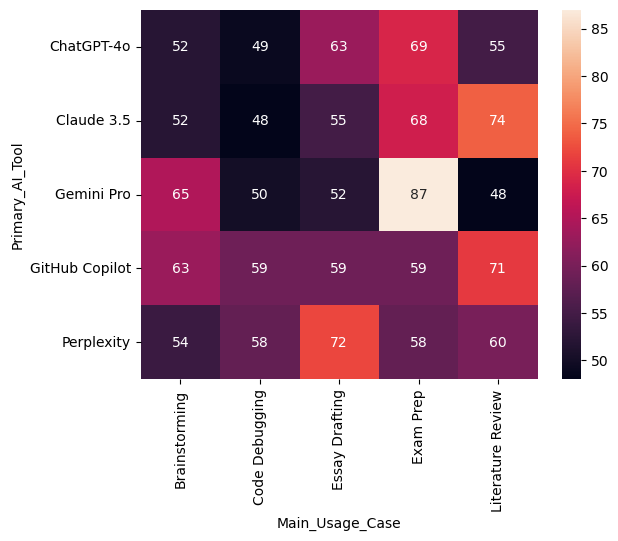

In [86]:
sns.heatmap(df.groupby(["Primary_AI_Tool","Main_Usage_Case"]).size().unstack(),annot=True)
plt.show()

Araçlar tamamen farklı işlere ayrışmıyor, ama zayıf eğilimler var.

In [87]:
df.groupby("Primary_AI_Tool")["Time_Saved_Hours_Weekly"].mean().sort_values(ascending=False)

Primary_AI_Tool
Perplexity        8.847682
Gemini Pro        8.642384
GitHub Copilot    8.440514
ChatGPT-4o        8.329861
Claude 3.5        8.279461
Name: Time_Saved_Hours_Weekly, dtype: float64

AI araçları arasında verimlilik (time saved) açısından büyük fark yoktur.

In [88]:
df.groupby("Main_Usage_Case")["Time_Saved_Hours_Weekly"].mean().sort_values(ascending=True)

Main_Usage_Case
Code Debugging       8.287879
Literature Review    8.422078
Exam Prep            8.445748
Brainstorming        8.622378
Essay Drafting       8.760797
Name: Time_Saved_Hours_Weekly, dtype: float64

In [89]:
df.groupby("AI_Ethics_Num")["Dif_GPA"].mean().sort_values(ascending=False)

AI_Ethics_Num
2    0.097547
3    0.088790
1    0.077706
Name: Dif_GPA, dtype: float64

Hiç endişe yok → belki yüzeysel kullanım

Orta endişe → dengeli ve bilinçli kullanım (en verimli)

Çok yüksek endişe → çekinme,kısıtlı kullanım

In [90]:
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score,AI_Ethics_Num,Dif_GPA
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3,2,0.00
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4,2,0.01
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7,3,0.00
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5,1,0.20
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9,3,0.20


In [91]:
df.groupby("Major")["Main_Usage_Case"].value_counts().unstack()

Main_Usage_Case,Brainstorming,Code Debugging,Essay Drafting,Exam Prep,Literature Review
Major,,,,,
Biology,53,41,56,63,46
Business Administration,50,45,55,55,51
Data Science,50,45,46,69,49
Fine Arts,43,52,47,65,56
Modern History,44,39,52,39,47
Software Engineering,46,42,45,50,59


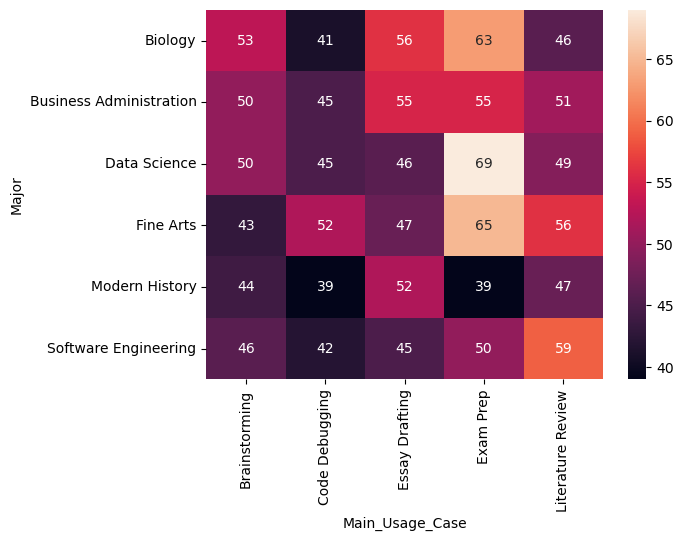

In [92]:
sns.heatmap(df.groupby(["Major","Main_Usage_Case"]).size().unstack(),annot=True)
plt.show()

In [93]:
df.groupby("Age")["AI_Ethics_Num"].mean().sort_values(ascending=False)

Age
21    2.021858
20    2.015000
22    1.989418
19    1.983871
23    1.983696
18    1.962366
24    1.954023
25    1.944444
Name: AI_Ethics_Num, dtype: float64

In [94]:
df.groupby("Major")["Task_Frequency_Daily"].mean().sort_values(ascending=False)

Major
Software Engineering       5.669421
Modern History             5.547511
Business Administration    5.546875
Data Science               5.335907
Biology                    5.200772
Fine Arts                  5.186312
Name: Task_Frequency_Daily, dtype: float64

In [95]:
df.groupby("Major")["Primary_AI_Tool"].value_counts().unstack()

Primary_AI_Tool,ChatGPT-4o,Claude 3.5,Gemini Pro,GitHub Copilot,Perplexity
Major,,,,,
Biology,54,45,58,50,52
Business Administration,47,57,35,55,62
Data Science,43,52,63,53,48
Fine Arts,47,59,44,62,51
Modern History,53,41,50,39,38
Software Engineering,44,43,52,52,51


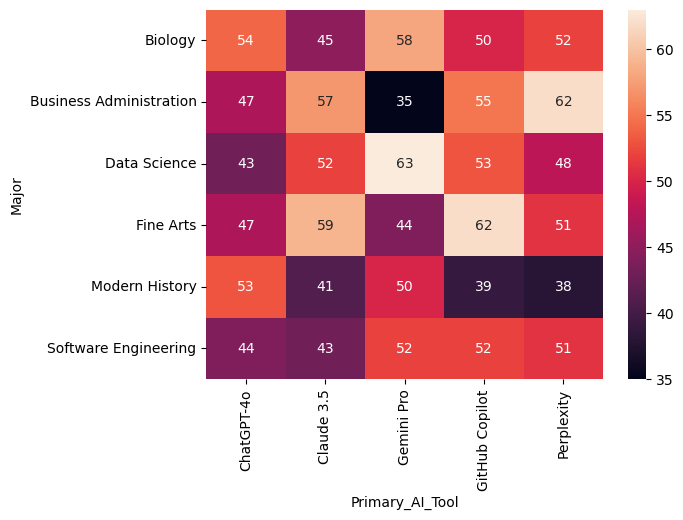

In [96]:
sns.heatmap(df.groupby(["Major","Primary_AI_Tool"]).size().unstack(),annot=True)
plt.show()

In [97]:
df.groupby("Primary_AI_Tool")["AI_Ethics_Num"].mean().sort_values(ascending=False)

Primary_AI_Tool
Perplexity        2.023179
ChatGPT-4o        2.006944
GitHub Copilot    1.980707
Gemini Pro        1.973510
Claude 3.5        1.925926
Name: AI_Ethics_Num, dtype: float64

In [98]:
df.groupby("Primary_AI_Tool")["Dif_GPA"].mean().sort_values(ascending=False)

Primary_AI_Tool
ChatGPT-4o        0.094063
Perplexity        0.092020
GitHub Copilot    0.090772
Gemini Pro        0.081722
Claude 3.5        0.080168
Name: Dif_GPA, dtype: float64

In [99]:
df.groupby("Task_Frequency_Daily")["Career_Confidence_Score"].mean()

Task_Frequency_Daily
1     5.171975
2     5.238095
3     5.597403
4     5.571429
5     5.180645
6     5.335714
7     5.487179
8     5.819277
9     5.525974
10    5.239437
Name: Career_Confidence_Score, dtype: float64

In [100]:
df.groupby("AI_Ethics_Concern")["Career_Confidence_Score"].mean().sort_values(ascending=False)

AI_Ethics_Concern
High      5.475806
Low       5.401530
Medium    5.374220
Name: Career_Confidence_Score, dtype: float64

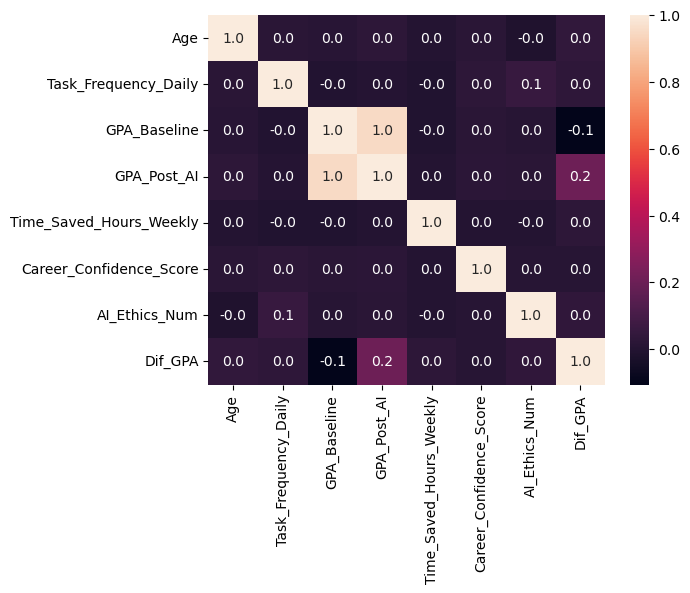

In [101]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt="1.1f")
plt.show()

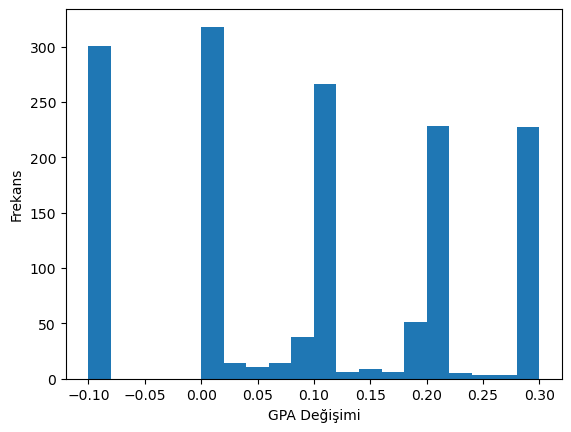

In [102]:
plt.hist(df["Dif_GPA"],bins=20)
plt.xlabel("GPA Değişimi")
plt.ylabel("Frekans")
plt.show()

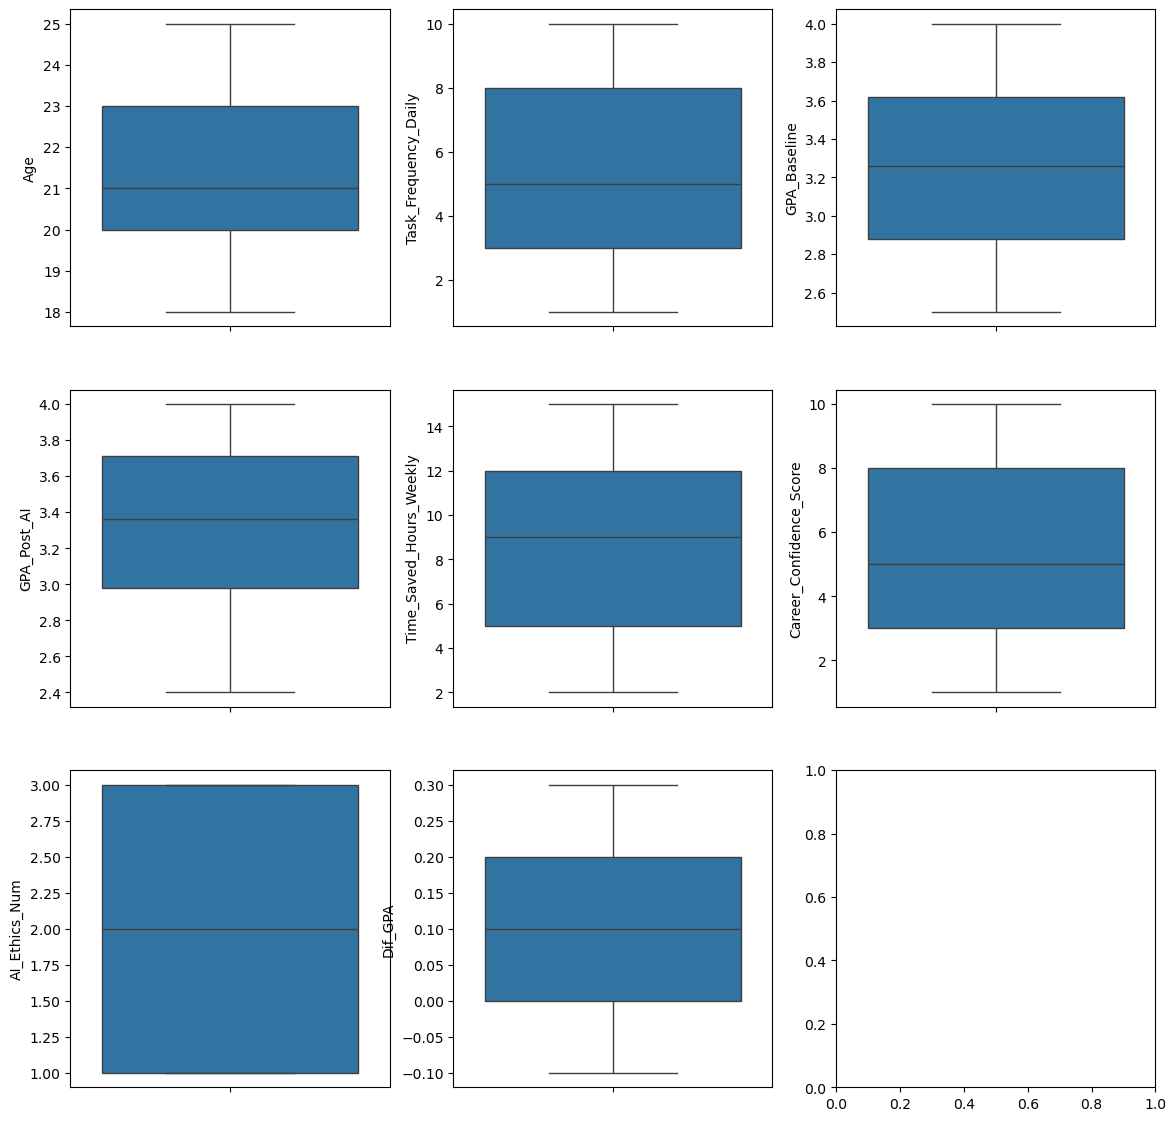

In [103]:
numeric_df=df.select_dtypes(include="number")

columns=3


fig,axes=plt.subplots(3,3,figsize=(14,14))
ax=axes.flatten()
"""
# nrows=3, ncols=3 → axes böyle görünür:
[[ax1, ax2, ax3],
 [ax4, ax5, ax6],
 [ax7, ax8, ax9]]

# flatten() sonrası:
[ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]
"""
#0 a
#1 b Enumerate kullanrak hem indexini hem de değerini aldık
#2 c

for i, col in enumerate(numeric_df.columns):
    sns.boxplot(y=numeric_df[col],ax=ax[i])
plt.show()

*************AI******

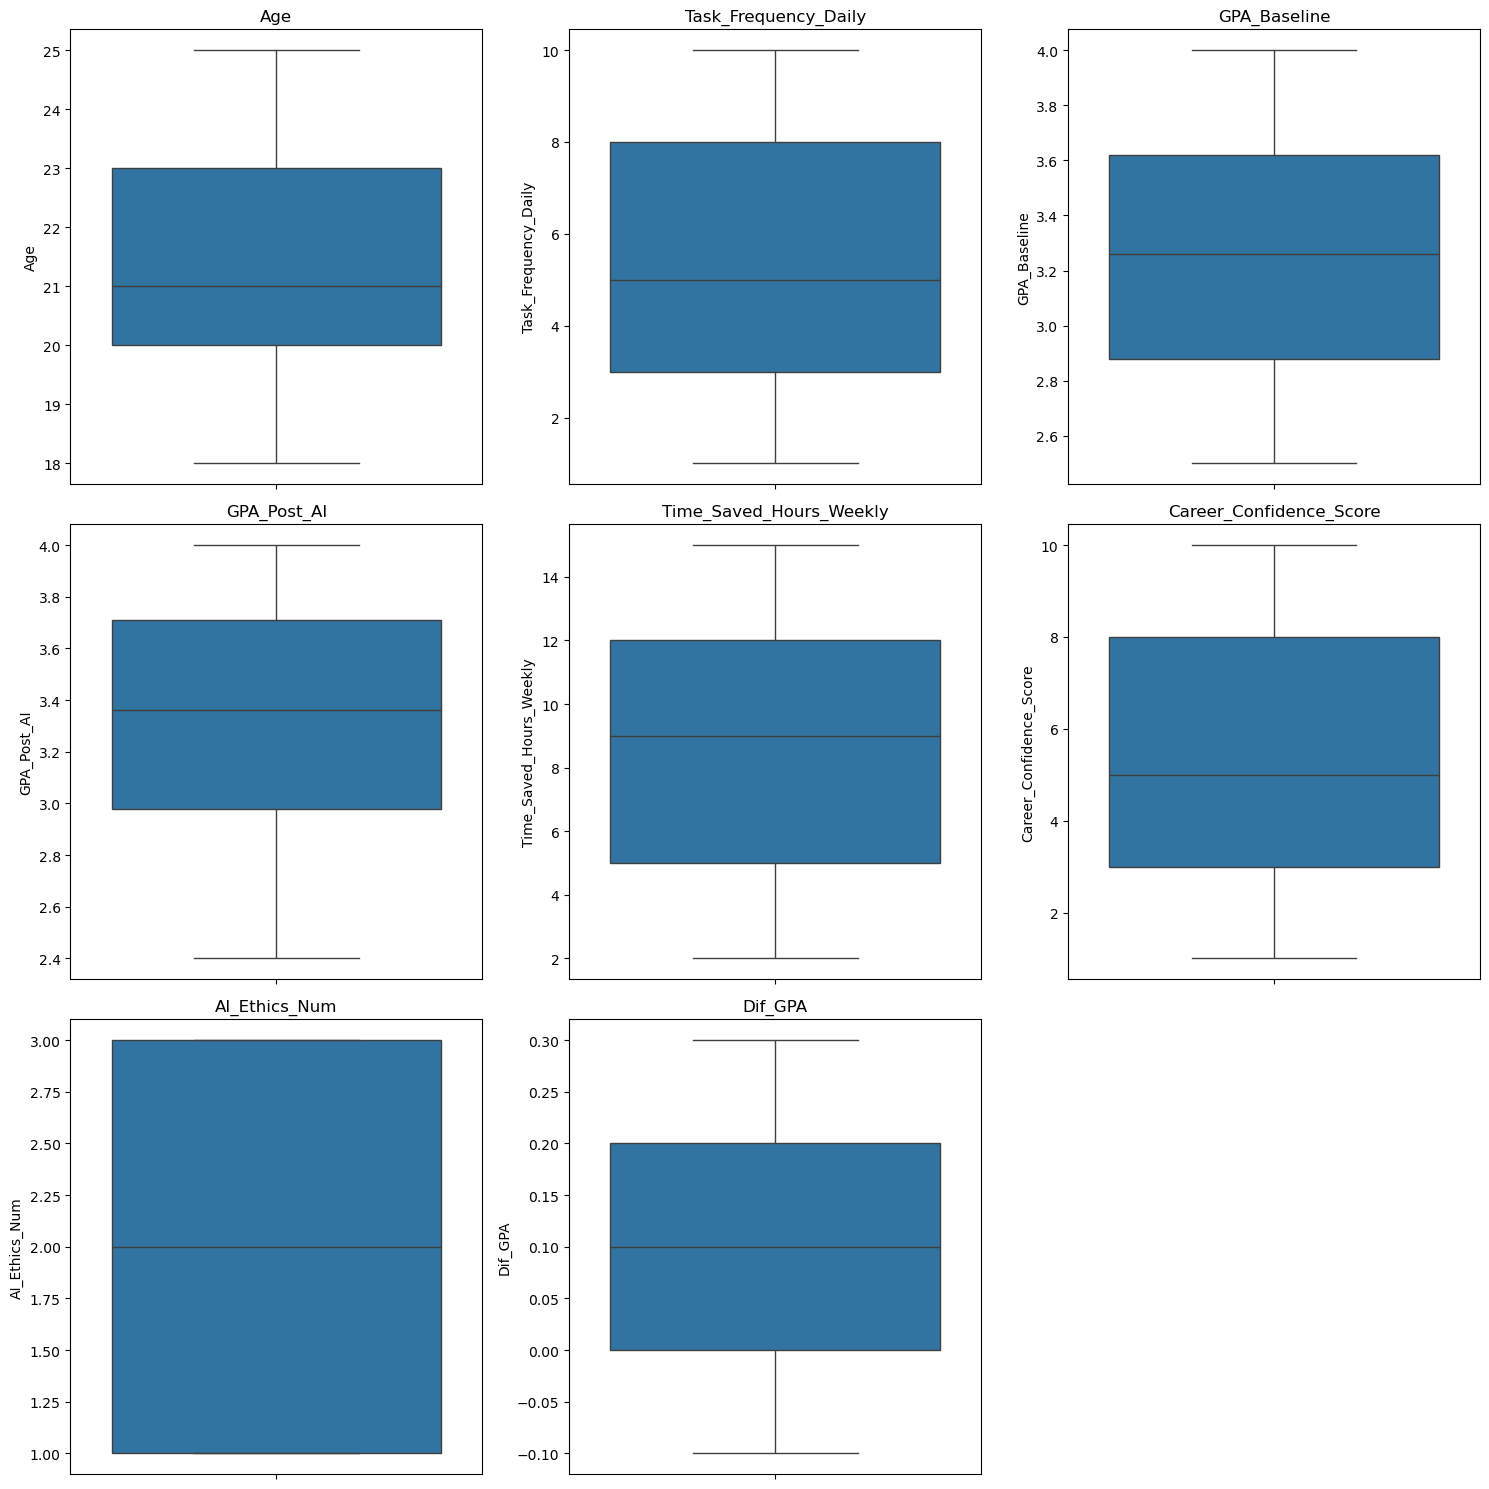

In [104]:
numeric_df = df.select_dtypes(include="number")
cols = numeric_df.columns
ncols = 3
nrows = -(-len(cols) // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)

for ax in axes.flatten()[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

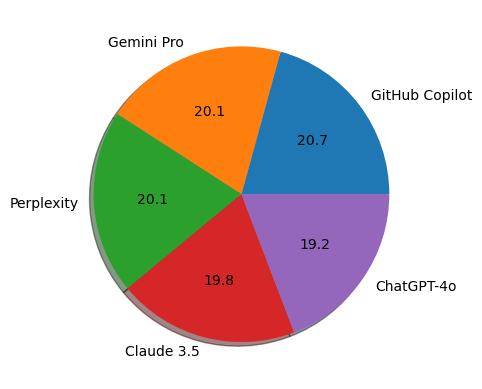

In [105]:
AI_Pay=df["Primary_AI_Tool"].value_counts()
plt.pie(x=AI_Pay.values,labels=AI_Pay.index,autopct="%1.1f",shadow=True)
plt.show()

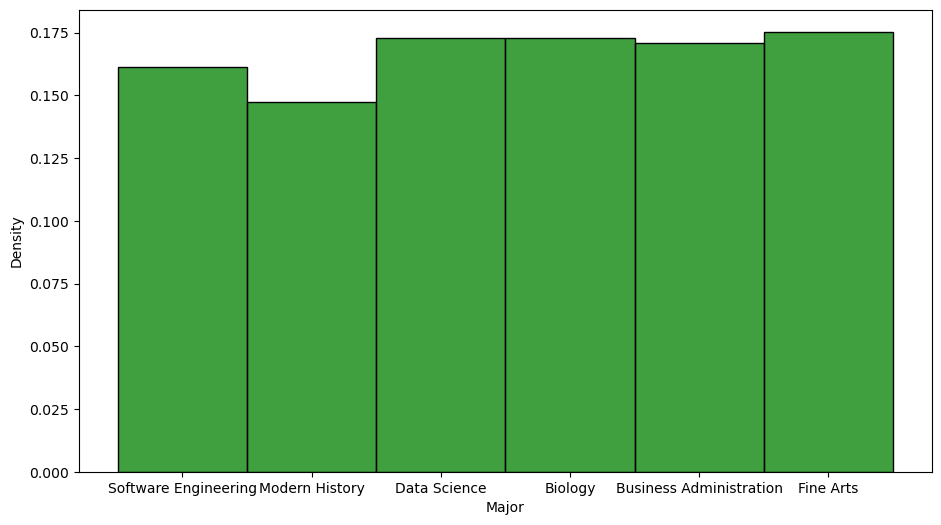

In [106]:
plt.figure(figsize=(11,6))
sns.histplot(x="Major",data=df,stat="density",color="green")
plt.show()

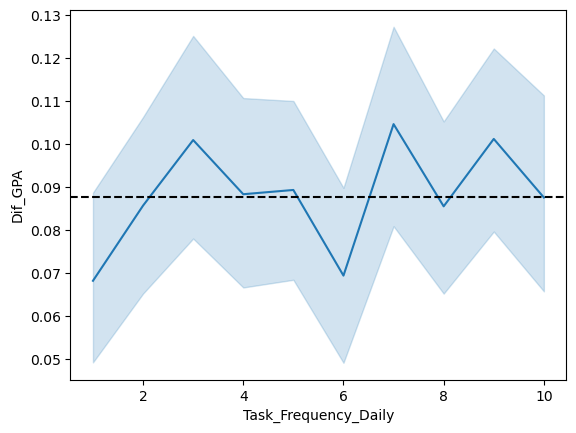

In [107]:
sns.lineplot(x="Task_Frequency_Daily",y="Dif_GPA",data=df)
plt.axhline(y=df["Dif_GPA"].mean(),
            linestyle="--",
            color="black"
           )
plt.show()

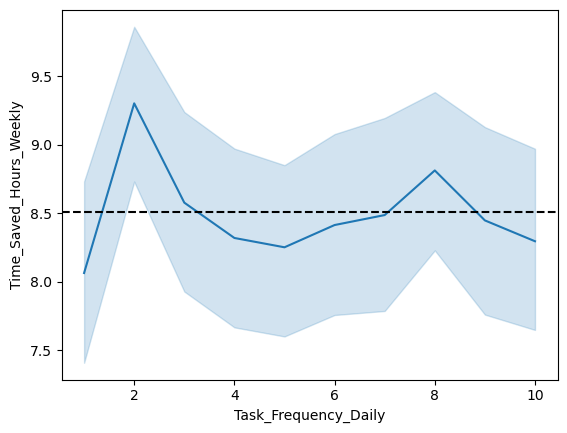

In [108]:
sns.lineplot(x="Task_Frequency_Daily",y="Time_Saved_Hours_Weekly",data=df)
plt.axhline(y=df["Time_Saved_Hours_Weekly"].mean(),
            linestyle="--",
            color="black"
           )
plt.show()

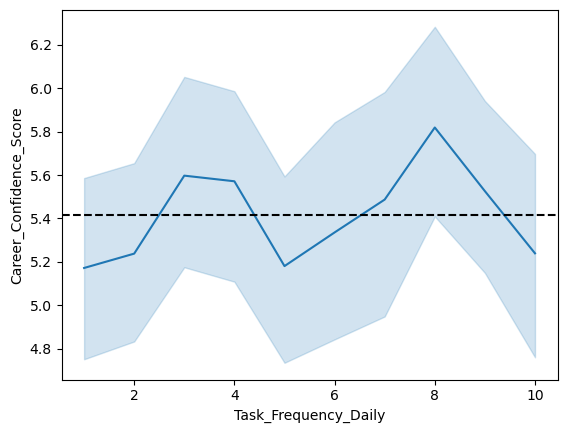

In [109]:
sns.lineplot(x="Task_Frequency_Daily",y="Career_Confidence_Score",data=df)
plt.axhline(y=df["Career_Confidence_Score"].mean(),linestyle="--",color="black")
plt.show()

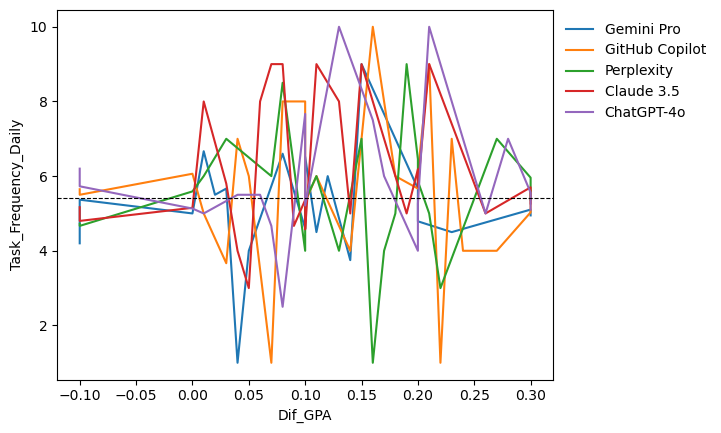

In [110]:
sns.lineplot(x="Dif_GPA",y="Task_Frequency_Daily",data=df,hue="Primary_AI_Tool",errorbar=None)
plt.legend(bbox_to_anchor=(1,1),framealpha=0)
plt.axhline(y=df["Task_Frequency_Daily"].mean(),color="black",linestyle="--",lw=0.8)
plt.show()

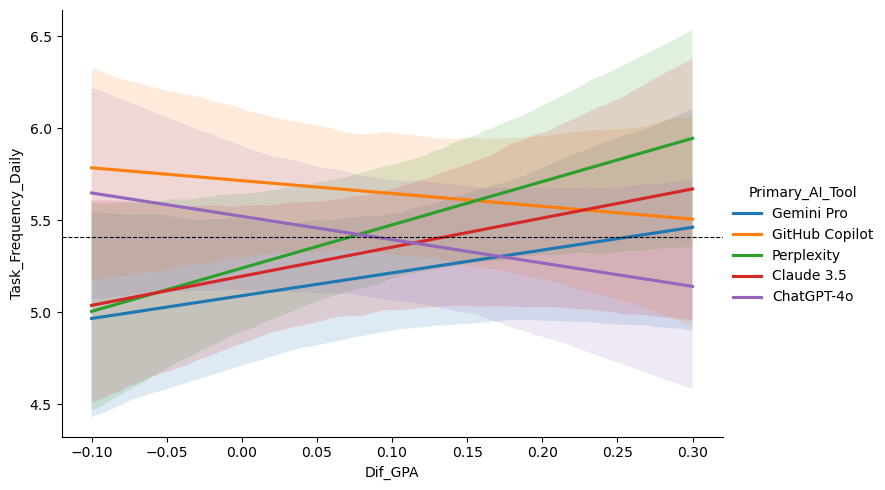

In [111]:
sns.lmplot(x="Dif_GPA", y="Task_Frequency_Daily", data=df, 
           hue="Primary_AI_Tool", scatter=False, height=5, aspect=1.5)
plt.axhline(y=df["Task_Frequency_Daily"].mean(), color="black", linestyle="--", lw=0.8)
plt.show()

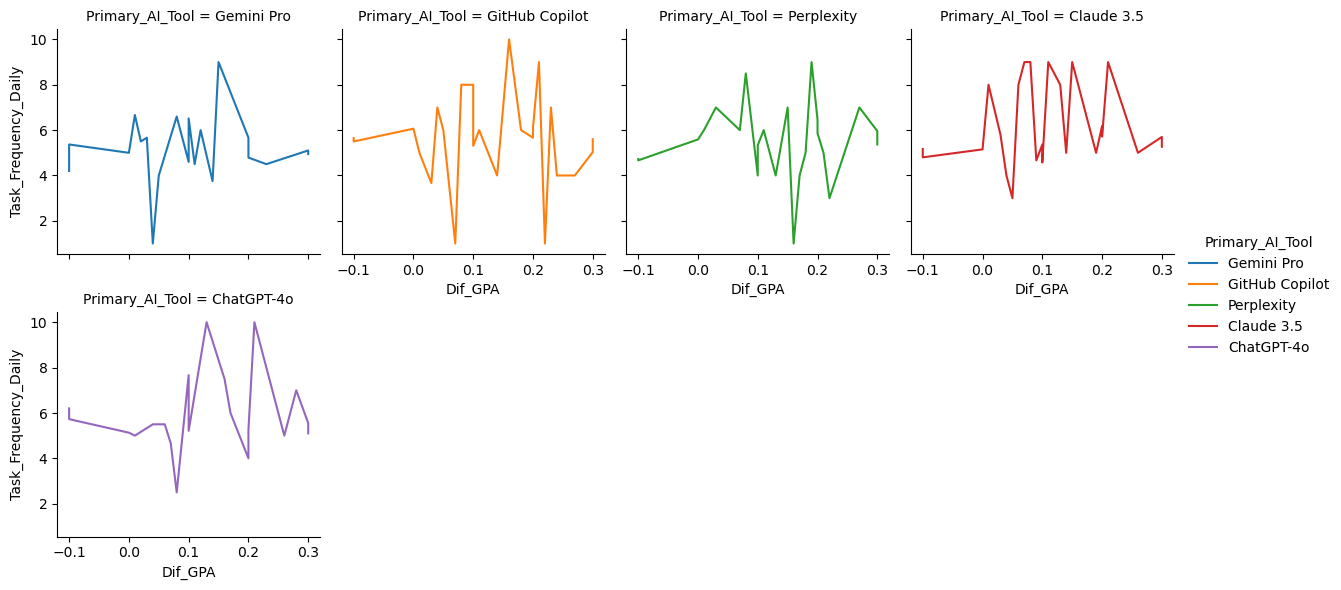

In [112]:
sns.relplot(x="Dif_GPA", y="Task_Frequency_Daily", data=df, 
            hue="Primary_AI_Tool", col="Primary_AI_Tool", 
            col_wrap=4, kind="line", errorbar=None, height=3)
plt.show()

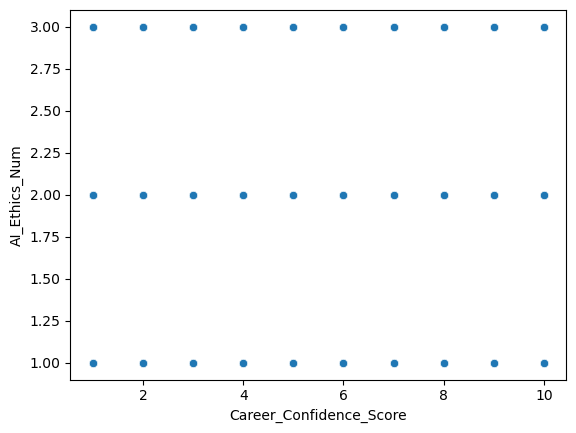

In [113]:
sns.scatterplot(data=df,y="AI_Ethics_Num",x="Career_Confidence_Score")
plt.show()

**************AI*******************

In [114]:
from scipy import stats

# GPA_Post_AI ve GPA_Baseline sütunları ile Bağımlı T-Testi
t_stat, p_value = stats.ttest_rel(df["GPA_Post_AI"], df["GPA_Baseline"])

print(f"T-İstatistiği: {t_stat:.4f}")
print(f"P-Değeri: {p_value:.4f}")

if p_value < 0.05:
    print("Sonuç: Yapay zeka kullanımı sonrası GPA'deki artış istatistiksel olarak anlamlıdır!")
else:
    print("Sonuç: GPA'deki değişim istatistiksel olarak anlamlı değildir (şans eseri olabilir).")

T-İstatistiği: 25.2037
P-Değeri: 0.0000
Sonuç: Yapay zeka kullanımı sonrası GPA'deki artış istatistiksel olarak anlamlıdır!


In [115]:
# Bölümlere (Major) göre 'Dif_GPA' değerlerini ayrı listeler (gruplar) haline getirelim
gruplar = [group["Dif_GPA"].values for name, group in df.groupby("Major")]

# ANOVA testini uygulayalım (*gruplar ifadesi listeyi fonksiyona argüman olarak açar)
f_stat, p_value = stats.f_oneway(*gruplar)

print(f"F-İstatistiği: {f_stat:.4f}")
print(f"P-Değeri: {p_value:.4f}")

if p_value < 0.05:
    print("Sonuç: Bölümler arasında GPA artışı açısından istatistiksel olarak anlamlı bir FARK VARDIR.")
else:
    print("Sonuç: Bölümler arasında GPA artışı açısından anlamlı bir FARK YOKTUR.")

F-İstatistiği: 1.2968
P-Değeri: 0.2626
Sonuç: Bölümler arasında GPA artışı açısından anlamlı bir FARK YOKTUR.


In [116]:
# Pearson korelasyon testini uygulayalım
corr_coef, p_value = stats.pearsonr(df["AI_Ethics_Num"], df["Career_Confidence_Score"])

print(f"Korelasyon Katsayısı (r): {corr_coef:.4f}")
print(f"P-Değeri: {p_value:.4f}")

if p_value < 0.05:
    print("Sonuç: İki metrik arasında istatistiksel olarak anlamlı bir İLİŞKİ VARDIR.")
    if corr_coef < 0:
        print("Detay: Bu ilişki negatiftir (Biri artarken diğeri azalır).")
    else:
        print("Detay: Bu ilişki pozitiftir (Birlikte artıp azalırlar).")
else:
    print("Sonuç: İki metrik arasında anlamlı bir ilişki YOKTUR.")

Korelasyon Katsayısı (r): 0.0106
P-Değeri: 0.6816
Sonuç: İki metrik arasında anlamlı bir ilişki YOKTUR.
